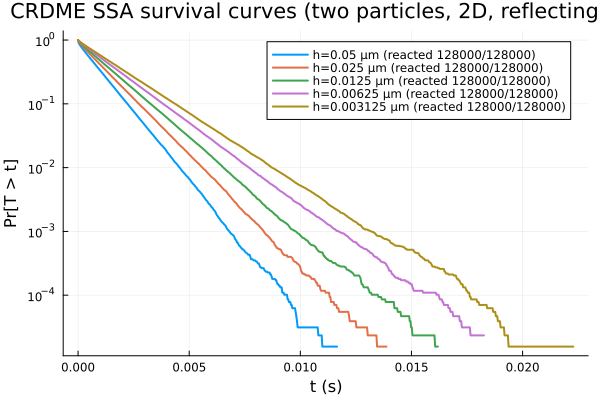

In [2]:
using Random
using Statistics
using Plots

function rdme_ssa_two_particles_2D_reflecting(
    rng::AbstractRNG;
    L::Float64,
    h::Float64,
    DA::Float64,
    DB::Float64,
    λ::Float64,
    ε::Float64,
    Tfinal::Float64 = Inf,
    init_same_voxel_ok::Bool = true
)
    N = Int(ceil(L / h))

    κA = DA / (h*h)
    κB = DB / (h*h)

    thresh = (ε / h)^2

    ax = rand(rng, 1:N); ay = rand(rng, 1:N)
    bx = rand(rng, 1:N); by = rand(rng, 1:N)

    if !init_same_voxel_ok
        while ax == bx && ay == by
            bx = rand(rng, 1:N); by = rand(rng, 1:N)
        end
    end

    dx = bx - ax
    dy = by - ay

    t = 0.0
    while t < Tfinal
        # Hopping propensities
        degA = 4 - (ax==1) - (ax==N) - (ay==1) - (ay==N)
        degB = 4 - (bx==1) - (bx==N) - (by==1) - (by==N)
        RhA = κA * 4
        RhB = κB * 4


        # Reaction propensity
        r2 = dx*dx + dy*dy
        if r2 <= thresh
            Rreact = λ
        else
            Rreact = 0.0
        end

        Rtot = RhA + RhB + Rreact
        if Rtot <= 0.0
            return Tfinal, false
        end

        # Time to next event
        t += randexp(rng)/Rtot
        if t >= Tfinal
            return Tfinal, false
        end

        # Select event
        r = rand(rng) * Rtot

        if r < Rreact
            return t, true
        end
        r -= Rreact

        if r < RhA
            old_ax, old_ay = ax, ay
            if rand(rng)<0.5
                ax += rand(rng, (-1, 1))
            else
                ay += rand(rng, (-1, 1))
            end
            ax = clamp(ax, 1, N)
            ay = clamp(ay, 1, N)
            dx -= (ax - old_ax)
            dy -= (ay - old_ay)

        else
            old_bx, old_by = bx, by
            if rand(rng)<0.5
                bx += rand(rng, (-1, 1))
            else
                by += rand(rng, (-1, 1))
            end
            bx = clamp(bx, 1, N)
            by = clamp(by, 1, N)
            dx += (bx - old_bx)
            dy += (by - old_by)
        end
    end

    return Tfinal, false
end


function sample_rdme_reaction_times_2D_reflecting(;
    L::Float64, h::Float64, DA::Float64, DB::Float64,
    λ::Float64, ε::Float64,
    nsims::Int = 100_000, Tfinal::Float64 = 0.05, seed::Int = 1,
    init_same_voxel_ok::Bool = true
)
    rng = MersenneTwister(seed)
    Ts = Vector{Float64}(undef, nsims)
    reacted = 0
    for i in 1:nsims
        t, ok = rdme_ssa_two_particles_2D_reflecting(
            rng; L=L, h=h, DA=DA, DB=DB, λ=λ, ε=ε,
            Tfinal=Tfinal, init_same_voxel_ok=init_same_voxel_ok
        )
        Ts[i] = t
        if ok == true
            reacted += 1
        end
    end
    return Ts, reacted
end

function survival_curve(Ts::Vector{Float64}, tgrid::AbstractVector{<:Real})
    n = length(Ts)
    S = Vector{Float64}(undef, length(tgrid))
    for (i, t) in enumerate(tgrid)
        S[i] = count(x -> x > t, Ts) / n
    end
    return max.(S, 1e-12)
end


function main()
    # Physical parameters
    L  = 0.2          
    D  = 10.0         
    rb = 1e-3         
    λ  = 1e9          
    ε  = rb           

    hs = [1e-3/0.02, 1e-3/0.04, 1e-3/0.08, 1e-3/0.16, 1e-3/0.32] 

    nsims  = 128_000
    Tfinal = 0.03
    tgrid  = range(0.0, Tfinal; length=1000)

    plt = plot(
        xlabel = "t (s)",
        ylabel = "Pr[T > t]",
        yscale = :log10,
        legend = :topright,
        title  = "CRDME SSA survival curves (two particles, 2D, reflecting BC)"
    )

    for (idx, h) in enumerate(hs)
        Ts, reacted = sample_rdme_reaction_times_2D_reflecting(
            L=L, h=h, DA=D, DB=D,
            λ=λ, ε=ε,
            nsims=nsims, Tfinal=Tfinal, seed=idx,
            init_same_voxel_ok=true
        )
        S = survival_curve(Ts, tgrid)
        mask = S .> 1e-5
        plot!(plt, tgrid[mask], S[mask]; lw=2, label="h=$(h) μm (reacted $(reacted)/$(nsims))")
    end

    display(plt)
end

main()